## Altair

### Общее описание

**Altair** — это библиотека для построения статистических визуализаций в Python, основанная на спецификации [*Vega-Lite*](https://vega.github.io/vega-lite/) — декларативном языке описания интерактивной графики. Благодаря этому *Altair* позволяет создавать выразительные и эстетически привлекательные визуализации с минимальным объёмом кода.

Основная идея *Altair* — декларативный подход: вы описываете, как данные должны быть визуализированы, а не как строить график шаг за шагом. Вся визуализация представляется как JSON-структура по стандарту *Vega-Lite*, которая затем отображается в Jupyter (например, через ipyvega), обеспечивая плавную интерактивность.

Ключевые особенности:
- Работа с табличными данными: *Altair* ожидает, что данные представлены в виде *DataFrame* в «аккуратном» [(tidy)](https://vita.had.co.nz/papers/tidy-data.pdf) формате, где:
    - каждая строка — это наблюдение,
    - каждый столбец — переменная (признак).
- Типизация данных: столбцы могут иметь типы: количественный (Q), порядковый (O), номинальный (N) или временной (T). Это помогает *Altair* делать разумные предположения при построении графиков.
- Сопоставление данных и визуальных каналов: вы указываете, какие поля из данных отображаются на осях, цветах, размерах, формах и других графических элементах. Агрегации (среднее, сумма и т.д.) задаются прямо в спецификации, аналогично SQL или группировкам в *polars/pandas*.
- Автоматические выводы: *Altair* анализирует данные и предлагает подходящие типы визуализаций и масштабы, что ускоряет исследование и снижает необходимость ручной настройки.

**Важно.** *Altair*, относительно, не требует глубокого знания графических API для простого построения графиков. Вместо этого он смещает акцент на подготовку данных: преобразование данных в tidy-формат, и визуализация станет простой и интуитивной. Хотя этот подход может показаться непривычным в начале, он обеспечивает единообразие и гибкость в долгосрочной перспективе.

Подробнее ознакомиться можно по ссылкам:
1. [Vega-Altair: Declarative Visualization in Python](https://altair-viz.github.io/)
2. [GitHub](https://github.com/altair-viz/altair-tutorial)

### Построение графиков - методы пространств имен plot

In [6]:
import altair as alt
import polars as pl
from datetime import datetime, timedelta
import random

Сгенерируем набор данных:

In [7]:
# Устанавливаем seed для воспроизводимости
random.seed(42)

# Генерация дат за 60 дней
start_date = datetime(2025, 9, 1)
dates = [start_date + timedelta(days=i) for i in range(60)]

# Категории товаров
categories = ["Electronics", "Clothing", "Books", "Home"]

# Генерация данных
data = []
for i, date in enumerate(dates):
    category = random.choice(categories)
    # Базовый спрос зависит от категории
    base_price = {"Electronics": 300, "Clothing": 80, "Books": 25, "Home": 120}[category]
    price = base_price + random.uniform(-20, 20)  # небольшой шум
    units_sold = max(1, int(50 - (price - base_price) * 0.5 + random.gauss(0, 5)))
    revenue = round(price * units_sold, 2)
    data.append({
        "date": date,
        "category": category,
        "price": round(price, 2),
        "units_sold": units_sold,
        "revenue": revenue
    })

# Создаём Polars DataFrame
df = pl.DataFrame(data)

print(df.head(4))

shape: (4, 5)
┌─────────────────────┬─────────────┬────────┬────────────┬──────────┐
│ date                ┆ category    ┆ price  ┆ units_sold ┆ revenue  │
│ ---                 ┆ ---         ┆ ---    ┆ ---        ┆ ---      │
│ datetime[μs]        ┆ str         ┆ f64    ┆ i64        ┆ f64      │
╞═════════════════════╪═════════════╪════════╪════════════╪══════════╡
│ 2025-09-01 00:00:00 ┆ Electronics ┆ 281.0  ┆ 58         ┆ 16298.02 │
│ 2025-09-02 00:00:00 ┆ Electronics ┆ 307.07 ┆ 49         ┆ 15046.33 │
│ 2025-09-03 00:00:00 ┆ Electronics ┆ 303.62 ┆ 50         ┆ 15180.99 │
│ 2025-09-04 00:00:00 ┆ Clothing    ┆ 80.21  ┆ 50         ┆ 4010.71  │
└─────────────────────┴─────────────┴────────┴────────────┴──────────┘


Для быстрого построения графиков в пространстве имен plot (`df.plot`) доступны следующие методы:
- `df.plot.bar()`: выводит столбчатую диаграмму с  накоплениями или группами;
- `df.plot.line()`: выводит линейный график;
- `df.plot.point(`): выводит точечную диаграмму, или диаграмму рассеяния, для сравнения двух переменных;
- `df.plot.scatter()`: синоним метода `df.plot.point()`.

Построим графики при помощи данных методов.

Линейный график - ежедневная выручка:

In [21]:
df.plot.line(
    x="date",
    y="revenue"
)

alt.Chart(...)

 Bar chart - суммарная выручка по категориям:

In [22]:
df.plot.bar(
    x="category",
    y="revenue"
)

alt.Chart(...)

Scatter plot - зависимость цены от количества проданных единиц:

In [23]:
df.plot.scatter(
    x="price",
    y="units_sold",
    color="category"
)

alt.Chart(...)

Методы вида `df.plot.line()`, `df.plot.bar()` и `df.plot.scatter()` - это удобный способ быстро построить базовый график прямо из *DataFrame*, не выходя из цепочки обработки данных. Они особенно полезны на этапе разведочного анализа, когда нужно мгновенно увидеть тренд, распределение или зависимость.

Однако важно понимать:
эти методы - упрощённый интерфейс поверх *Altair*. Они автоматически настраивают типы данных, оси и базовую стилистику, делая «разумные предположения» на основе содержимого *DataFrame*.

Если вам нужна полная гибкость, например, настраивать оси, добавлять заголовки, менять цветовые палитры, комбинировать несколько слоёв, создавать взаимодействия (zoom, tooltips, фильтрация) или строить сложные мультипанельные визуализации, то следует использовать полноценный **API Altair**: `alt.Chart(df)`.

In [25]:
chart = alt.Chart(df).mark_line().encode(
    x="date:T",
    y="revenue:Q"
).properties(title="Продажи по дням")

chart.show()

alt.Chart(...)

### Построение графиков - полноценный API Altair

Если необходимо настроить внешний вид, стилизовать элементы, добавить интерактивность или подготовить визуализацию для публикации, одной строки недостаточно.

Такие задачи требуют более глубокого взаимодействия с *API Altair*. В следующем примере построим линейный график с множеством настроек:
- формат даты на оси X,
- стиль линии и точек,
- всплывающие подсказки,
- отключение сетки и засечек,
- размеры, заголовки, шрифты.

Пример:

In [45]:
chart = alt.Chart(df)\
    .mark_line(                                   # Указываем тип графика — линия
        point=True,                               # Показывать точки на линии (для наглядности)
        strokeWidth=2,                            # Толщина линии (в пикселях)
        color='#4285b4'                           # Цвет линии (можно задать и в encode)
    )\
    .encode(
        x=alt.X(                                  # Настройка оси X
            "date:T",                             # Поле 'date' как временная метка (T = Temporal)
            title="Дата",                         # Подпись оси X
            axis=alt.Axis(                        # Настройка внешнего вида оси
                format='%d.%m',                   # Формат отображения даты (например: "01.09")
                labelAngle=0,                     # Угол наклона подписей (для компактности)
                ticks=False                       # Убираем засечки на оси X
            )
        ),
        y=alt.Y(                                  # Настройка оси Y
            "revenue:Q",                          # Поле 'revenue' как количественное (Q = Quantitative)
            title="Выручка (₽)",                  # Подпись оси Y
            scale=alt.Scale(                      # Настройка шкалы (например, диапазон)
                zero=False                        # Не привязывать ось Y к 0 (для лучшего масштаба)
            )
        ),
        tooltip=[                                                    # Всплывающая подсказка при наведении
            alt.Tooltip("date:T", title="Дата"),                     # Отображать дату
            alt.Tooltip("revenue:Q", title="Выручка", format=".2f")  # Выручка с 2 знаками после запятой
        ]
    )\
    .properties(                                                     # Свойства всего графика
        title={                                                      # Настройка заголовка
            "text": ["Ежедневная выручка"],                          # Текст заголовка (можно массивом для многострочности)
            "subtitle": "Динамика продаж за 60 дней",                # Подзаголовок
            "anchor": "start"                                        # Выравнивание заголовка по левому краю
        },
        width=800,                                # Ширина графика (в пикселях)
        height=400                                # Высота графика (в пикселях)
    )\
    .configure_axis(                             # Настройка стиля осей
        labelFontSize=12,                        # Размер шрифта подписей осей
        titleFontSize=14,                        # Размер шрифта названий осей
        grid=False                               # Отключить сетку
    )\
    .configure_title(                            # Настройка стиля заголовка
        fontSize=16,                             # Размер шрифта заголовка
        anchor='start'                           # Выравнивание заголовка
    )\
    .configure_view(                              # Настройка внешнего вида области графика
        stroke=None                               # Убираем рамку (границу) вокруг всего графика
    )

# Отображение графика
chart.show()

alt.Chart(...)

Этот график еще не идеален, его можно улучшить.

Данный подход - мощный инструмент для создания настраиваемых, интерактивных и профессиональных визуализаций. Он требует больше кода, но открывает огромные возможности для анализа и презентации данных.

**Примечание.** Если мы хотим сделать график более интерактивным в конце необходимо добавить метод `interactive()`.

*Altair* предоставляет ряд базовых свойств mark:
- `mark_arc()`: Круговая диаграмма (пай-чарт).
- `mark_area()`: Заполненный график области (простая стековая диаграмма области).
- `mark_bar()`: Столбчатая диаграмма.
- `mark_circle()`: Диаграмма рассеяния с закрашенными кругами.
- `mark_geoshape()`: Географическая карта.
- `mark_image()`: Диаграмма рассеяния с изображениями в качестве маркеров.
- `mark_line()`: Линейный график.
- `mark_point()`: Диаграмма рассеяния с настраиваемой формой точек.
- `mark_rect()`: Тепловая карта.
- `mark_rule()`: График "японские свечи".
- `mark_square()`: Диаграмма рассеяния с закрашенными квадратами.
- `mark_text()`: Столбчатая диаграмма с подписями.
- `mark_tick()`: Простой стрип-график.
- `mark_trail()`: Линейный график с изменяющимся размером.
- `mark_boxplot()`: Ящик с усами.
- `mark_errorband()`: Линейный график с полосой доверительного интервала.
- `mark_errorbar()`: Столбцы с интервалами доверия.

### Ограничения Altair

В библиотеке *Altair* по умолчанию стоит ограничение на 5000 строк в фрейме данных, что предотвращает проблемы при работе с объемными данными. Это ограничение продиктовано не самой библиотекой *Altair*, а языком *Vega-Lite*. Но при необходимости можно обойти - нужно изменить параметр `max_rows` следующим образом:
`alt.data_transformers.disable_max_rows()`

В результате ограничение будет снято, что позволит *Altair* работать с большими наборами данных. Но будьте осторожны, поскольку обработка объемных
данных может негативно сказаться на производительности системы.

## hvPlot

**hvPlot** отличается от большинства графических библиотек тем, что не создаёт визуализации самостоятельно. Вместо этого он предоставляет единый, унифицированный интерфейс, который перенаправляет запросы на три популярные библиотеки: Bokeh, Matplotlib и Plotly. При этом его API сознательно повторяет стиль построения графиков в *pandas*, что делает его интуитивно понятным для пользователей, уже знакомых с этим фреймворком. Общая архитектура пакета **hvPlot**:

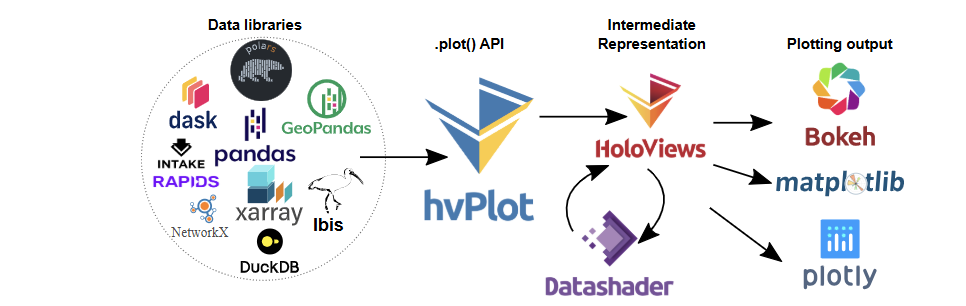

Графические методы библиотеки **hvPlot** принимают на вход структуры данных из *polars*, *pandas* и других компонентов экосистемы PyData. На основе этих данных с помощью *HoloViews* создаётся промежуточное представление визуализации: своего рода «план» отображения, который зависит от выбранной целевой библиотеки. На этом этапе, при работе с большим объёмом данных (например, при построении карт с миллионами точек), может задействоваться библиотека Datashader для эффективного рендеринга.

Далее это промежуточное представление преобразуется в конкретные инструкции для одной из графических библиотек: *Bokeh*, *Matplotlib* или *Plotly*. Это позволяет гибко настраивать внешний вид графиков, используя особенности синтаксиса выбранного инструмента. Завершающим шагом становится непосредственное построение визуализации: процесс, в ходе которого «сырые» данные превращаются в наглядные изображения на экране.

Импортируем библиотеку:

In [6]:
import hvplot.polars

После импорта **hvPlot** к *DataFrame* добавится новый метод - `.hvplot`, который позволяет создавать сложные визуализации напрямую из набора данных. 

Возьмём известный набор данных - Титаник.

In [16]:
df = pl.read_csv("https://raw.githubusercontent.com/m-ardat/Library_Polars/main/dataset/TitanicDataset.csv")

df.head(4)

PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
i64,i64,i64,str,str,f64,i64,i64,str,f64,str,str
1,0,3,"""Braund, Mr. Owen Harris""","""male""",22.0,1,0,"""A/5 21171""",7.25,null,"""S"""
2,1,1,"""Cumings, Mrs. John Bradley (Fl…","""female""",38.0,1,0,"""PC 17599""",71.2833,"""C85""","""C"""
3,1,3,"""Heikkinen, Miss. Laina""","""female""",26.0,0,0,"""STON/O2. 3101282""",7.925,null,"""S"""
4,1,1,"""Futrelle, Mrs. Jacques Heath (…","""female""",35.0,1,0,"""113803""",53.1,"""C123""","""S"""


### Построение графиков

Пространство **hvplot** включает следующие методы:
- `hvplot.area()`: выводит диаграмму с  областями, отличающуюся от линейного графика цветовым заполнением области под кривой и опциональной возможностью показывать накопление;
- `hvplot.bar()`: выводит столбчатую диаграмму с накоплениями или группами;
- `hvplot.bivariate()`: выводит двумерный график плотности распределения по набору точек;
- `hvplot.box()`: выводит диаграмму размаха (ящики с усами) для сравнения распределений двух или нескольких переменных;
- `hvplot.density()`: выводит ядерную оценку плотности для одной или нескольких переменных;
- `hvplot.heatmap()`: выводит тепловую карту, помогающую визуализировать переменную по двум независимым измерениям;
- `hvplot.hexbins()`: выводит тепловую карту на основе шестиугольников;
- `hvplot.hist()`: выводит гистограмму распределения переменной;
- `hvplot.line()`: выводит линейный график (как для временных рядов);
- `hvplot.scatter()`: выводит диаграмму рассеяния для сравнения двух переменных;
- `hvplot.violin()`: выводит скрипичную диаграмму для сравнения распределений переменных с использованием ядерной оценки плотности.

#### Диаграмма рассеяния

Диаграммы рассеяния или точечная диаграмма идеально подходит для сравнения двух непрерывных переменных. Для её построения необходимо применить метод `hvplot.scatter`. Пример:

In [49]:
df.hvplot.scatter(
    x="Age",
    y="Fare",
    color="Survived",
    cmap=['orange', 'blue'],                                   # оранжевый = погиб, синий = выжил
    alpha=0.6,                                                 # Прозрачность точек
    title='Возраст vs Стоимость билета (цвет — выживаемость)', # Заголовок
    xlabel="Возраст",                                          # Наименование оси Ox
    ylabel="Стоимость билета"                                  # Наименование оси Oy
)

:Scatter   [Age]   (Fare,Survived)

Первые три аргумента являются самыми важными, поскольку с их помощью мы определяем переменные, которые будут выводиться на осях, а также переменную,
уникальные значения которой будут выделяться разными цветами.

#### Cтолбчатая диаграмма

Построим столбчатую диаграмму, на которой увидим выживаемость по полу. Для это преобразуем наш фрейм данных, а затем воспользуемся методом `hvplot.bar`

In [54]:
df\
    .select(["Sex", "Survived"])\
    .group_by(pl.col("Sex"))\
    .agg(pl.sum("Survived"))\
    .hvplot.bar(x='Sex', y='Survived', title='Выживаемость по полу')

:Bars   [Sex]   (Survived)

Первые два параметра являются самыми важными, поскольку с их помощью мы определяем переменные, которые будут выводиться на осях.

#### Гистограмма 

Построим гистограмму распределение возрастов среди выживших и погибших. Для этого воспользуемся методом `hvplot.hist`.

In [39]:
df.hvplot.hist(y='Age', by='Survived', alpha=0.5, title='Распределение возраста по выживаемости')

:NdOverlay   [Survived]
   :Histogram   [Age]   (Count)

Первые параметр указывает, что по оси Oy будет отображаться возраст, а второй - группирует данные в зависимости от переменной 'Survived', указывая, выжили ли пассажиры.

### Изменение движка hvPlot

По умолчанию библиотека **hvPlot** использует движок *Bokeh*, что в большинстве случаев подходит для визуализации. Однако иногда может возникнуть необходимость сменить движок на *Plotly* или *Matplotlib*. Например, *Matplotlib* может быть полезен, когда интерактивность не требуется, или когда необходимо сохранить единый стиль с другими графиками. Изменить движок можно с помощью метода `hvplot.extension()`, передав ему строку `"matplotlib"` или `"plotly"`, или `"bokeh"`. Для этого сначала нужно явно импортировать пакет **hvplot**.

In [43]:
import hvplot
hvplot.extension("matplotlib")

Построим столбчатую диаграмму, нос использованием движка *Matplotlib*:

:Bars   [Sex]   (Survived)
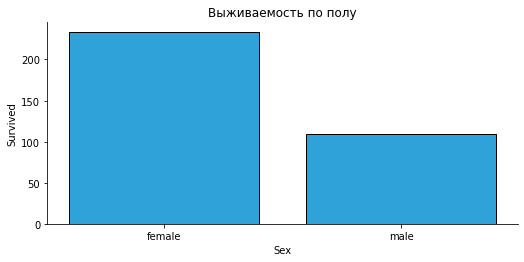

In [44]:
df\
    .select(["Sex", "Survived"])\
    .group_by(pl.col("Sex"))\
    .agg(pl.sum("Survived"))\
    .hvplot.bar(x='Sex', y='Survived', title='Выживаемость по полу')

Или же на *Plotly*:

In [51]:
hvplot.extension("plotly")

df\
    .select(["Sex", "Survived"])\
    .group_by(pl.col("Sex"))\
    .agg(pl.sum("Survived"))\
    .hvplot.bar(x='Sex', y='Survived', title='Выживаемость по полу')

:Bars   [Sex]   (Survived)